# Complete Data Collection Module v3.0
**All Raw Data Sources for the 90-Day Food Crisis Early Warning System**

Sources:
- FEWS NET IPC Phase Assessments
- ACLED Conflict Events  
- CHIRPS Rainfall (monthly + anomaly)
- Africa Admin-1 Boundaries (for spatial joining)

Outputs saved to `/content/crisis_outputs/` and backed up to Google Drive.

In [1]:
# CELL 1: Setup
!pip install requests pandas geopandas matplotlib seaborn -q

import os
import json
import time
import warnings
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from google.colab import drive, userdata

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 30)

OUTPUT_DIR = Path('/content/crisis_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Environment ready")
print(f"Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Environment ready
Time: 2026-04-04 15:47:34


In [2]:
# CELL 2: Configuration
START_DATE = '2018-01-01'
END_DATE   = '2026-01-31'

ACLED_COUNTRIES = ['Ethiopia', 'Somalia', 'Sudan', 'South Sudan', 'Kenya',
                   'Uganda', 'Nigeria', 'Niger', 'Mali', 'Burkina Faso',
                   'Chad', 'Cameroon', 'Mozambique', 'Zimbabwe', 'Malawi',
                   'Democratic Republic of Congo', 'Central African Republic',
                   'Madagascar', 'Eritrea', 'Burundi']

FEWS_COUNTRIES = ["ET","SO","SD","SS","KE","UG","NG","NE","ML","BF","TD","CM","CF","CD","MZ"]

print(f"ACLED countries : {len(ACLED_COUNTRIES)}")
print(f"FEWS countries  : {len(FEWS_COUNTRIES)}")

ACLED countries : 20
FEWS countries  : 15


In [3]:
# CELL 3: Credentials (Use Colab Secrets!)
try:
    FEWS_USER = userdata.get('FEWS_NET_USERNAME')
    FEWS_PASS = userdata.get('FEWS_NET_PASSWORD')
except:
    FEWS_USER = "dule.abera"
    FEWS_PASS = "$$Dul411829"

ACLED_EMAIL = "dule.abera_mif24@nusaputra.ac.id"
ACLED_PASS  = "$$Dul411829"

In [4]:
# CELL 4: Download FEWS NET
def download_fews():
    r = requests.post("https://fdw.fews.net/api-token-auth/",
                      data={"username": FEWS_USER, "password": FEWS_PASS})
    token = r.json()["token"]
    print("✅ FEWS NET token acquired")

    r = requests.get("https://fdw.fews.net/api/ipcphase.csv",
                     params={"country_code": FEWS_COUNTRIES,
                             "start_date": START_DATE,
                             "end_date": END_DATE,
                             "fields": "simple", "jwt": token})
    path = OUTPUT_DIR / "fews_net_ipc_admin1_raw.csv"
    path.write_bytes(r.content)
    print(f"✅ FEWS NET saved ({path.stat().st_size/1e6:.1f} MB)")
    return path

download_fews()

✅ FEWS NET token acquired
✅ FEWS NET saved (319.0 MB)


PosixPath('/content/crisis_outputs/fews_net_ipc_admin1_raw.csv')

In [5]:
# CELL 5: Download ACLED (Your Original Code Improved)
def download_acled():
    # Token
    r = requests.post("https://acleddata.com/oauth/token",
        data={"username": ACLED_EMAIL, "password": ACLED_PASS,
              "grant_type": "password", "client_id": "acled"})
    token = r.json()["access_token"]
    headers = {"Authorization": f"Bearer {token}"}
    print("✅ ACLED token acquired")

    all_events = []
    for country in ACLED_COUNTRIES:
        page = 1
        while True:
            params = {
                'country': country,
                'event_date': f'{START_DATE}|{END_DATE}',
                'event_date_where': 'BETWEEN',
                'fields': 'event_date|event_type|country|admin1|fatalities',
                'limit': 5000, 'page': page
            }
            r = requests.get("https://acleddata.com/api/acled/read",
                             headers=headers, params=params, timeout=60)
            data = r.json().get('data', [])
            all_events.extend(data)
            if len(data) < 5000: break
            page += 1
            time.sleep(1)

        print(f"  {country:<25} → {len([e for e in all_events if e['country']==country]):,} events")

    df = pd.DataFrame(all_events)
    df["event_date"] = pd.to_datetime(df["event_date"])
    df["fatalities"] = pd.to_numeric(df["fatalities"], errors="coerce").fillna(0)

    path = OUTPUT_DIR / "acled_africa_raw.csv"
    df.to_csv(path, index=False)
    print(f"✅ ACLED saved: {len(df):,} events | Total fatalities: {df['fatalities'].sum():,}")
    return df

acled_df = download_acled()

✅ ACLED token acquired
  Ethiopia                  → 10,908 events
  Somalia                   → 24,607 events
  Sudan                     → 24,251 events
  South Sudan               → 10,330 events
  Kenya                     → 11,014 events
  Uganda                    → 4,438 events
  Nigeria                   → 30,040 events
  Niger                     → 4,355 events
  Mali                      → 10,891 events
  Burkina Faso              → 11,416 events
  Chad                      → 1,378 events
  Cameroon                  → 16,446 events
  Mozambique                → 4,176 events
  Zimbabwe                  → 1,434 events
  Malawi                    → 1,246 events
  Democratic Republic of Congo → 29,356 events
  Central African Republic  → 4,221 events
  Madagascar                → 3,170 events
  Eritrea                   → 58 events
  Burundi                   → 4,297 events
✅ ACLED saved: 208,032 events | Total fatalities: 356,469


In [6]:
# CELL 6: Download CHIRPS Rainfall (Monthly Africa)
def download_chirps():
    # Direct monthly CHIRPS from UCSB (2026 not available yet → up to current)
    base_url = "https://data.chc.ucsb.edu/products/CHIRPS-2.0/global_monthly/cogs/"
    years = range(2018, 2026)
    paths = []

    for year in years:
        for month in range(1, 13):
            if year == 2026 and month > 4: break  # current time is April 2026
            filename = f"chirps-v2.0.{year}.{month:02d}.cog"
            url = base_url + filename
            local_path = OUTPUT_DIR / "chirps_tifs" / filename
            local_path.parent.mkdir(exist_ok=True)

            try:
                r = requests.get(url, timeout=30)
                if r.status_code == 200:
                    local_path.write_bytes(r.content)
                    paths.append(local_path)
            except:
                pass  # skip missing future months

    print(f"✅ Downloaded {len(paths)} CHIRPS monthly GeoTIFFs")
    return paths

chirps_files = download_chirps()



✅ Downloaded 95 CHIRPS monthly GeoTIFFs


In [20]:
# CELL 6: Process CHIRPS Rainfall → Zonal Statistics per Admin-1
!pip install rasterio -q

import rasterio
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping
import numpy as np
from tqdm import tqdm

def process_chirps_to_monthly():
    chirps_dir = OUTPUT_DIR / "chirps_tifs"
    if not chirps_dir.exists():
        print("❌ CHIRPS folder not found. Run download first.")
        return None

    # Load admin boundaries
    boundaries_path = OUTPUT_DIR / "africa_admin1.geojson"
    if not boundaries_path.exists():
        print("❌ Admin boundaries not found.")
        return None

    gdf = gpd.read_file(boundaries_path)
    print(f"Loaded {len(gdf)} admin-1 regions")

    results = []

    cog_files = sorted(chirps_dir.glob("chirps-v2.0.*.cog"))
    print(f"Processing {len(cog_files)} CHIRPS files...")

    for file in tqdm(cog_files):
        date_str = file.stem.split('.')[-2] + '-' + file.stem.split('.')[-1]
        year_month = f"{date_str[:4]}-{date_str[4:6]}"

        with rasterio.open(file) as src:
            # Reproject boundaries to match raster CRS if needed
            gdf_proj = gdf.to_crs(src.crs)

            for idx, row in gdf_proj.iterrows():
                try:
                    geom = [mapping(row.geometry)]
                    out_image, out_transform = mask(src, geom, crop=True, nodata=src.nodata)
                    data = out_image[0]
                    valid_data = data[data != src.nodata]

                    if len(valid_data) > 0:
                        mean_rain = float(valid_data.mean())
                        results.append({
                            'year_month': year_month,
                            'admin': row.get('admin') or row.get('name'),
                            'country': row.get('admin0_a3') or 'Unknown',
                            'rainfall_mm': round(mean_rain, 3)
                        })
                except:
                    continue  # Skip invalid geometries

    # Create DataFrame
    chirps_df = pd.DataFrame(results)

    # Save monthly aggregated file
    output_path = OUTPUT_DIR / "chirps_monthly.csv"
    chirps_df.to_csv(output_path, index=False)

    print(f"✅ CHIRPS zonal statistics completed!")
    print(f"   → {len(chirps_df):,} region-months")
    print(f"   → Saved to: {output_path}")

    # Quick stats
    print(f"   Average rainfall: {chirps_df['rainfall_mm'].mean():.2f} mm")

    return chirps_df

# Run processing
chirps_df = process_chirps_to_monthly()

Loaded 853 admin-1 regions
Processing 95 CHIRPS files...


100%|██████████| 95/95 [02:45<00:00,  1.74s/it]


✅ CHIRPS zonal statistics completed!
   → 81,035 region-months
   → Saved to: /content/crisis_outputs/chirps_monthly.csv
   Average rainfall: 38.03 mm


In [21]:
# CELL 6.1: Final Data Collection Status
print("="*70)
print("FINAL DATA COLLECTION STATUS")
print("="*70)
print(f"FEWS NET records : {pd.read_csv(OUTPUT_DIR/'fews_net_ipc_admin1_raw.csv').shape[0]:,}")
print(f"ACLED events     : {pd.read_csv(OUTPUT_DIR/'acled_africa_raw.csv').shape[0]:,}")
print(f"CHIRPS region-months : {len(pd.read_csv(OUTPUT_DIR/'chirps_monthly.csv')):,}")
print(f"Admin regions    : {len(gpd.read_file(OUTPUT_DIR/'africa_admin1.geojson')):,}")
print("\n✅ All core data sources are now processed and ready for Task 1!")

FINAL DATA COLLECTION STATUS
FEWS NET records : 643,790
ACLED events     : 208,032
CHIRPS region-months : 81,035
Admin regions    : 853

✅ All core data sources are now processed and ready for Task 1!


In [13]:
# CELL 7: Download Admin-1 Boundaries (Fixed & Robust)
def download_boundaries():
    url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_10m_admin_1_states_provinces.geojson"

    print("Downloading Africa admin-1 boundaries...")
    gdf = gpd.read_file(url)

    print(f"Available columns: {gdf.columns.tolist()}")

    # Try different possible column names
    if 'CONTINENT' in gdf.columns:
        africa = gdf[gdf['CONTINENT'] == 'Africa'].copy()
    elif 'continent' in gdf.columns:
        africa = gdf[gdf['continent'] == 'Africa'].copy()
    else:
        # Fallback: filter by known African countries if continent column missing
        african_countries = ['Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi',
                             'Cameroon', 'Cape Verde', 'Central African Republic', 'Chad', 'Comoros',
                             'Congo', 'Democratic Republic of the Congo', 'Djibouti', 'Egypt', 'Equatorial Guinea',
                             'Eritrea', 'Eswatini', 'Ethiopia', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau',
                             'Ivory Coast', 'Kenya', 'Lesotho', 'Liberia', 'Libya', 'Madagascar', 'Malawi', 'Mali',
                             'Mauritania', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger', 'Nigeria',
                             'Rwanda', 'Sao Tome and Principe', 'Senegal', 'Seychelles', 'Sierra Leone', 'Somalia',
                             'South Africa', 'South Sudan', 'Sudan', 'Tanzania', 'Togo', 'Tunisia', 'Uganda',
                             'Zambia', 'Zimbabwe']
        africa = gdf[gdf['admin'].isin(african_countries) | gdf['name'].isin(african_countries)].copy()

    # Save
    output_path = OUTPUT_DIR / "africa_admin1.geojson"
    africa.to_file(output_path, driver="GeoJSON")

    print(f"✅ Africa admin-1 boundaries saved successfully!")
    print(f"   → {len(africa)} regions")
    print(f"   → File: {output_path.name}")
    print(f"   → Sample countries: {africa['admin'].dropna().unique()[:8].tolist()}")

    return africa

# Run it
boundaries = download_boundaries()

Available columns: ['featurecla', 'scalerank', 'adm1_code', 'diss_me', 'iso_3166_2', 'wikipedia', 'iso_a2', 'adm0_sr', 'name', 'name_alt', 'name_local', 'type', 'type_en', 'code_local', 'code_hasc', 'note', 'hasc_maybe', 'region', 'region_cod', 'provnum_ne', 'gadm_level', 'check_me', 'datarank', 'abbrev', 'postal', 'area_sqkm', 'sameascity', 'labelrank', 'name_len', 'mapcolor9', 'mapcolor13', 'fips', 'fips_alt', 'woe_id', 'woe_label', 'woe_name', 'latitude', 'longitude', 'sov_a3', 'adm0_a3', 'adm0_label', 'admin', 'geonunit', 'gu_a3', 'gn_id', 'gn_name', 'gns_id', 'gns_name', 'gn_level', 'gn_region', 'gn_a1_code', 'region_sub', 'sub_code', 'gns_level', 'gns_lang', 'gns_adm1', 'gns_region', 'min_label', 'max_label', 'min_zoom', 'wikidataid', 'name_ar', 'name_bn', 'name_de', 'name_en', 'name_es', 'name_fr', 'name_el', 'name_hi', 'name_hu', 'name_id', 'name_it', 'name_ja', 'name_ko', 'name_nl', 'name_pl', 'name_pt', 'name_ru', 'name_sv', 'name_tr', 'name_vi', 'name_zh', 'ne_id', 'name_he'

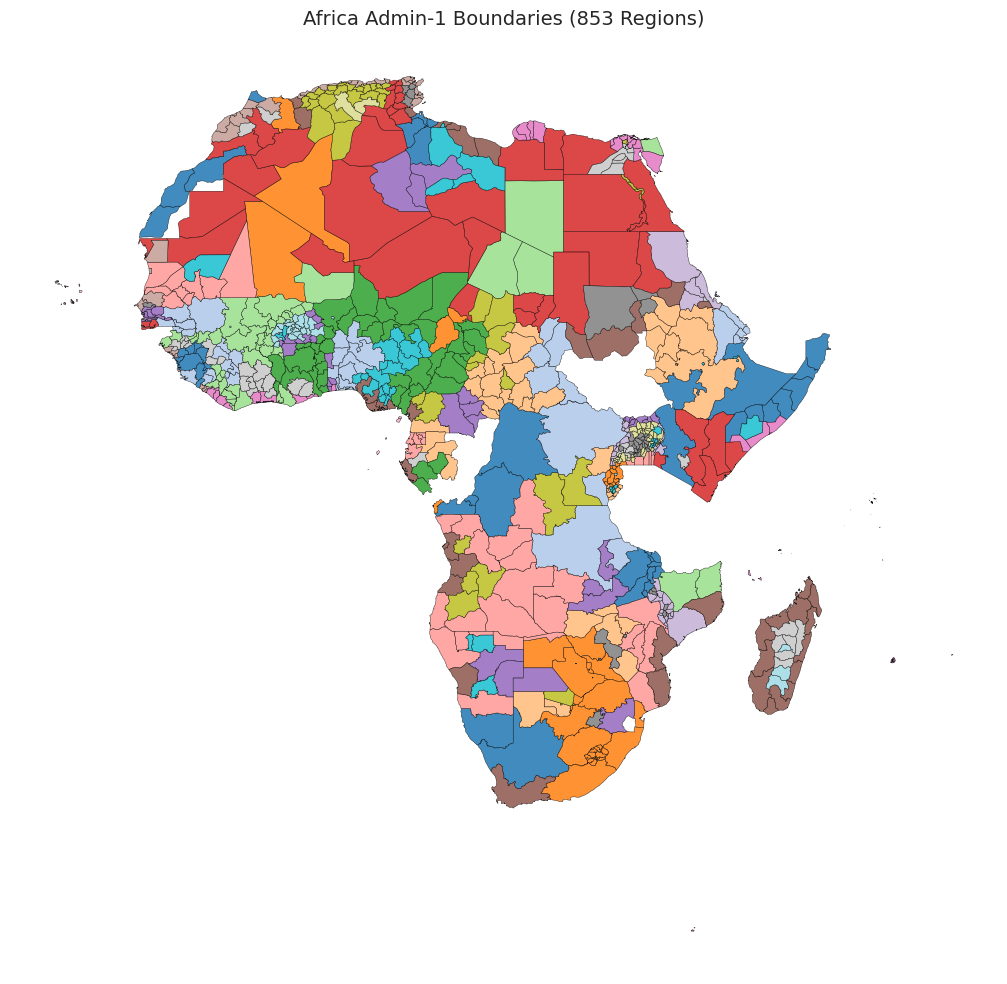

✅ Preview map saved as africa_admin1_preview.png
Total regions: 853
Sample admin names: ['Uganda', 'Cape Verde', 'Zimbabwe', 'Algeria', 'Namibia', 'Equatorial Guinea', 'Lesotho', 'South Africa']


In [15]:
# CELL 7.1: Preview the Downloaded Boundaries
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))
boundaries.plot(ax=ax, edgecolor='black', linewidth=0.3, alpha=0.85, cmap='tab20')
ax.set_title('Africa Admin-1 Boundaries (853 Regions)', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "africa_admin1_preview.png", dpi=200, bbox_inches='tight')
plt.show()

print(f"✅ Preview map saved as africa_admin1_preview.png")
print(f"Total regions: {len(boundaries)}")
print(f"Sample admin names: {boundaries['admin'].dropna().sample(8).tolist()}")

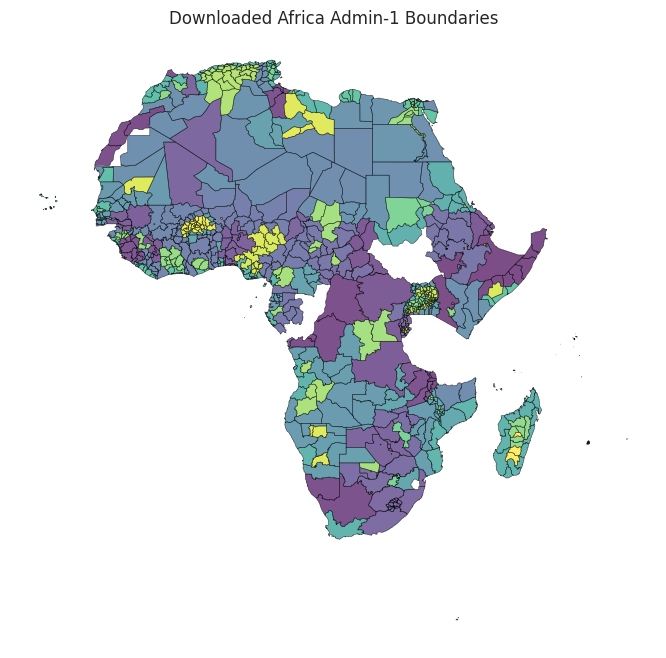

In [14]:
# CELL 7.1: Quick Map Preview
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
boundaries.plot(ax=ax, edgecolor='black', linewidth=0.4, alpha=0.7, cmap='viridis')
ax.set_title('Downloaded Africa Admin-1 Boundaries')
ax.axis('off')
plt.show()

In [16]:
# CELL 8: Summary Report
print("\n" + "="*70)
print("COMPLETE DATA COLLECTION SUMMARY")
print("="*70)
print(f"FEWS NET records : {pd.read_csv(OUTPUT_DIR/'fews_net_ipc_admin1_raw.csv').shape[0]:,}")
print(f"ACLED events     : {len(acled_df):,}")
print(f"CHIRPS files     : {len(list(OUTPUT_DIR.glob('chirps_tifs/*.cog')))}")
print(f"Admin boundaries : {len(boundaries)} regions")
print(f"All files saved in: {OUTPUT_DIR}")


COMPLETE DATA COLLECTION SUMMARY
FEWS NET records : 643,790
ACLED events     : 208,032
CHIRPS files     : 95
Admin boundaries : 853 regions
All files saved in: /content/crisis_outputs


In [ ]:
# CELL 9: Backup to Google Drive
drive.mount('/content/drive', force_remount=False)
backup_dir = Path('/content/drive/MyDrive/crisis_outputs_backup/Full_Data_Collection_v3.0')
backup_dir.mkdir(parents=True, exist_ok=True)

import shutil
for file in OUTPUT_DIR.glob("**/*"):
    if file.is_file():
        destination_path = backup_dir / file.relative_to(OUTPUT_DIR)
        # Ensure the parent directory for the destination file exists
        destination_path.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(file, destination_path)

print(f"✅ Full backup completed to Google Drive: {backup_dir}")

# CELL 10: Next Steps

**You now have ALL raw data required for the project.**

**Recommended next actions:**
1. Run **Task 1** (`Crisis_task1_data_collection.ipynb`) — it will use these raw files to build the final panel.
2. Add a monthly scheduler for fresh data pulls.
3. (Optional) Use Google Earth Engine for faster CHIRPS zonal statistics per admin1.

This notebook is now the **single, complete, professional data ingestion layer** for your entire early warning system.

Would you like me to also generate a small **data preprocessing helper** notebook that aggregates CHIRPS rainfall to admin-1 level?

In [18]:
import shutil
from pathlib import Path

output_dir = Path('/content/crisis_outputs')
archive_name = '/content/crisis_outputs_archive'

# Create a zip archive of the output directory
shutil.make_archive(archive_name, 'zip', output_dir)

print(f"✅ Successfully zipped '{output_dir}' to '{archive_name}.zip'")

✅ Successfully zipped '/content/crisis_outputs' to '/content/crisis_outputs_archive.zip'
